In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')

In [8]:
# Set aesthetic style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.family'] = 'sans-serif'

In [9]:
def load_and_preprocess_data(filepath):
    print(f"Loading data from {filepath}...")
    df = pd.read_csv(filepath)
    
    # Selecting numeric columns for clustering
    numeric_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 
                    'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
    
    # Drop rows with missing values in these columns if any
    data = df[numeric_cols].dropna()
    
    # Scaling the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    
    return data, scaled_data

In [10]:
def perform_kmeans(scaled_data, k_range=range(1, 11)):
    print("Performing K-Means Clustering...")
    
    # Elbow Method to find optimal K
    wcss = []
    for i in k_range:
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
        kmeans.fit(scaled_data)
        wcss.append(kmeans.inertia_)
    
    # Plotting Elbow Method
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, wcss, marker='o', linestyle='--', color='#2c3e50')
    plt.title('Elbow Method for Optimal K', fontsize=15, fontweight='bold')
    plt.xlabel('Number of Clusters (k)', fontsize=12)
    plt.ylabel('WCSS', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Let's assume k=3 or k=4 based on typical student performance groups (High, Medium, Low)
    optimal_k = 3
    kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    
    score = silhouette_score(scaled_data, labels)
    print(f"K-Means Silhouette Score: {score:.4f}")
    
    return labels, optimal_k

In [11]:
def perform_graph_clustering(scaled_data, n_clusters=3):
    print("Performing Graph-Based Clustering (Spectral Clustering)...")
    
    # Spectral clustering is computationally expensive on large datasets
    # We'll use a subset for this demonstration if samples > 2000
    spectral = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=42)
    labels = spectral.fit_predict(scaled_data)
    
    score = silhouette_score(scaled_data, labels)
    print(f"Spectral Clustering Silhouette Score: {score:.4f}")
    
    return labels

In [12]:
def visualize_clusters(data, labels, title):
    # Reducing dimensions to 2D using PCA for visualization
    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(data)
    
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels, cmap='viridis', s=50, alpha=0.6, edgecolors='w')
    plt.title(title, fontsize=15, fontweight='bold')
    plt.xlabel('Principal Component 1', fontsize=12)
    plt.ylabel('Principal Component 2', fontsize=12)
    plt.legend(*scatter.legend_elements(), title="Clusters")
    plt.grid(True, alpha=0.3)
    plt.show()

Loading data from student_data.csv...
Performing K-Means Clustering...


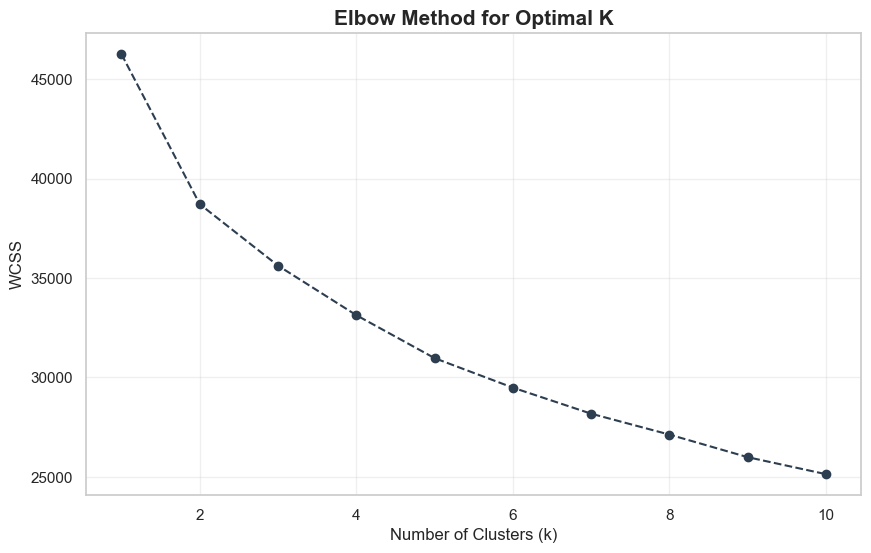

K-Means Silhouette Score: 0.1223


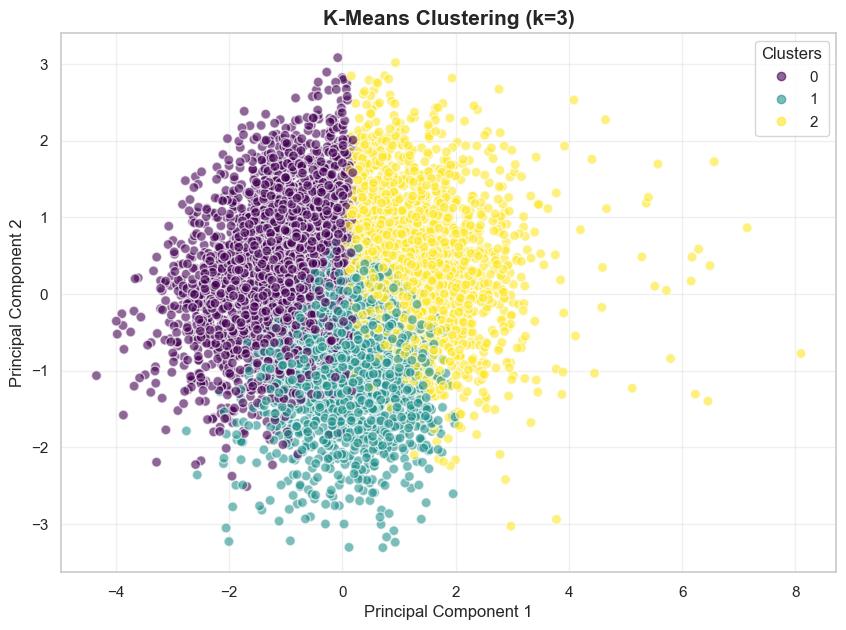

Performing Graph-Based Clustering (Spectral Clustering)...
Spectral Clustering Silhouette Score: 0.1470


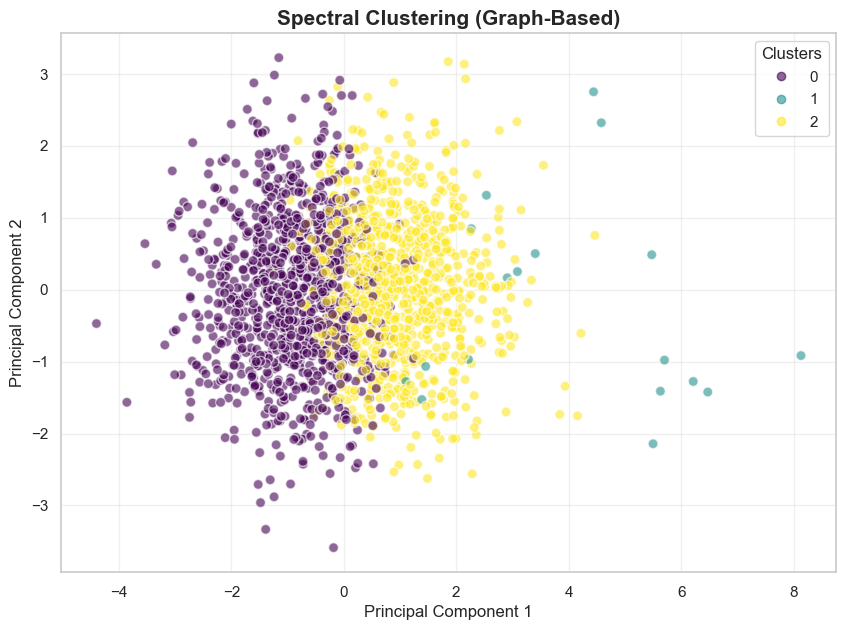


Clustering Completed Successfully.


In [13]:
filepath = 'student_data.csv'
raw_data, scaled_data = load_and_preprocess_data(filepath)

# K-Means
kmeans_labels, k = perform_kmeans(scaled_data)
visualize_clusters(scaled_data, kmeans_labels, f'K-Means Clustering (k={k})')

# Spectral (using subset for speed)
subset_size = 2000
spectral_data = scaled_data[:subset_size]
spectral_labels = perform_graph_clustering(spectral_data, n_clusters=3)
visualize_clusters(spectral_data, spectral_labels, 'Spectral Clustering (Graph-Based)')

print("\nClustering Completed Successfully.")